# Predictive maintenance - Sensor data review to estimate machine failure in advance

**Author**: Karthik

This notebook builds a machine learning model to predict m/c failure .

**Dataset**: https://www.kaggle.com/datasets/zara2099/iiot-sensor-data-for-predictive-maintenance?resource=download&select=simulated_iiot_dataset.csv

**Objective**: Predict the `machine_failure-Target variable` column (1 = Failure, 0 = Normal) using multiple machine health monitoring sensor data 

**Libraries used**: pandas, numpy, matplotlib, seaborn, scikit-learn, mcp

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

import kagglehub
import shap
import joblib
import os

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Download and Load the Dataset 

In [2]:
#Load the csv file, I have removed the time stamp check to simplify the dataset.
#I dont see time of the data influencing the failure. the temperature pattern is consistent and its not affected by 
#duration of the day. for applicatiotn where the time stamps is critical for.e g.g. out door machines, 
#it is advisable to inclulde and conver the hours into minutes for consistency.for some reson the model prefers minutes not sure why!
df = pd.read_csv("SENSOR IOTT.csv")
print(f"\nDataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df = df.drop('timestamp', axis=1)
df.head()


Dataset loaded successfully with 1000 rows and 17 columns.


,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1


In [3]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          1000 non-null   float64
 1   vibration            1000 non-null   float64
 2   pressure             1000 non-null   float64
 3   humidity             1000 non-null   float64
 4   rotation_speed       1000 non-null   float64
 5   voltage              1000 non-null   float64
 6   current              1000 non-null   float64
 7   oil_level            1000 non-null   float64
 8   load                 1000 non-null   float64
 9   motor_temperature    1000 non-null   float64
 10  gearbox_temperature  1000 non-null   float64
 11  sound_level          1000 non-null   float64
 12  fan_speed            1000 non-null   float64
 13  reactive_power       1000 non-null   float64
 14  active_power         1000 non-null   float64
 15  machine_failure      1000 non-null   int64  
dtype

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,75.096660,0.507084,30.017503,39.906404,1497.536318,219.532624,4.985922,70.096085,80.183418,59.939829,64.800457,74.966418,1200.436575,50.319840,100.311680,0.162000
std,4.896080,0.099745,2.950363,5.135663,49.619011,10.073892,0.512502,5.208700,10.116854,4.825616,4.852018,3.044218,48.661286,5.127844,10.074989,0.368635
min,58.793663,0.205961,20.941464,25.352757,1341.164809,191.004861,3.643694,51.558174,41.633445,40.387999,48.837173,64.873263,1060.851978,34.587189,66.704962,0.000000
25%,71.762048,0.439376,28.056001,36.312898,1465.869752,213.063072,4.622431,66.539219,73.631455,56.783329,61.565503,73.026418,1167.578101,46.849870,93.355223,0.000000
50%,75.126503,0.506308,29.999248,40.000923,1499.087900,219.571729,4.972627,70.024899,80.191240,60.021831,64.718429,74.903191,1200.553492,50.402801,100.112341,0.000000
75%,78.239719,0.572888,31.982746,43.334727,1531.956157,226.124468,5.349873,73.617006,86.772041,63.253711,68.061675,76.904721,1233.210037,53.686347,107.190268,0.000000
max,94.263657,0.819311,41.778713,56.215465,1655.645510,250.982994,6.764528,85.588406,113.773829,73.841868,79.570546,85.133305,1364.205910,67.144552,131.404229,1.000000


## Observation - Statistical summary (df.describe())

datas - 1000 rows and 17 columns.

1. Tempearture- Mean =75 deg C(assumed unit for all features) Range 58 to 94. opearting at high temperature. could be a feature with importance

2. Vibration - Mean 0.5 . evenly distributed
3. Pressure nothing significant
4. humidity - 39mean is uite humid, might create corrosion
5. rot.speed - stable
6. Voltage  - looks nominal from Mean value
7. current - mean is closer to higer limits, so heave load most likely
8. oil-level -Mean 70 - mini-51, low oil domination. could be consuming more oil. likely over worked, this ties with humidity and current asa a joint contribution factor
9. load-  Mean -80, once again heave ops signals are here, ties up with nicely iwth more current consumptiona and lubitcation consumption
10. Motor - heavey temperature, coul dbe poor lubricaiton or friction
11. Sound level - noisy!. again good indicator that compliments heavey current consumptio, lubrication , load
12. fan speed - high speed mean, tries hard to bring heat down
13. gear box temp - slighly high than motor, but its i expected as there more mech. frcition
14. reactive power - poor effecient
15. actiev power - mean 100- high
16. MAchine failure- Target. Mean  0.162- imbalanced dataset. recall will be the goto metric for evaluation
17. time stamp - I wil remove this







In [4]:
df.isnull().sum()

temperature            0
vibration              0
pressure               0
humidity               0
rotation_speed         0
voltage                0
current                0
oil_level              0
load                   0
motor_temperature      0
gearbox_temperature    0
sound_level            0
fan_speed              0
reactive_power         0
active_power           0
machine_failure        0
dtype: int64

In [5]:
df.columns
df['machine_failure'].value_counts()

machine_failure
0    838
1    162
Name: count, dtype: int64

In [6]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Dataset size before removing duplicates: {df.shape[0]}")

df = df.drop_duplicates()
print(f"Dataset size after removing duplicates: {df.shape[0]}")

Number of duplicate rows: 0
Dataset size before removing duplicates: 1000
Dataset size after removing duplicates: 1000


# . 3 Exploratory Data Analysis (EDA)


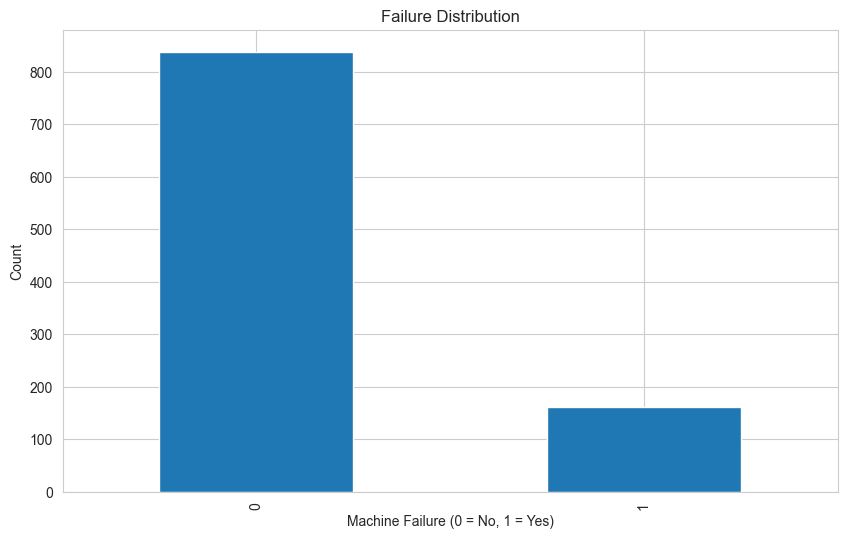

In [7]:
df['machine_failure'].value_counts().plot(kind='bar')
plt.title("Failure Distribution")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#The dataset is imbalanced, with fewer failure cases

In [8]:
# 3.1  Target Variable distribution - 

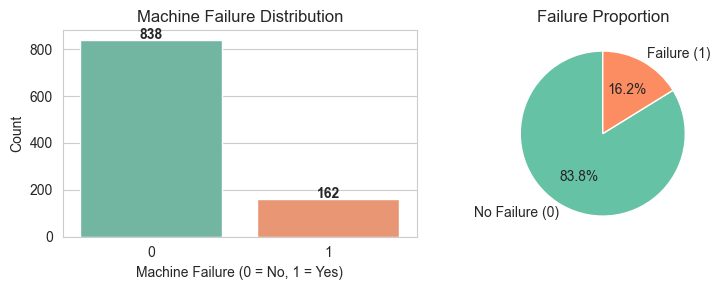

Class distribution:
machine_failure
0    838
1    162
Name: count, dtype: int64

Class balance ratio: 0.19


In [9]:


fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Count plot
target_counts = df['machine_failure'].value_counts()

sns.countplot(x='machine_failure', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Machine Failure Distribution')
axes[0].set_xlabel('Machine Failure (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

for i, count in enumerate(target_counts):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts,
            labels=['No Failure (0)', 'Failure (1)'],
            autopct='%1.1f%%',
            colors=sns.color_palette('Set2'),
            startangle=90)

axes[1].set_title('Failure Proportion')

plt.tight_layout()
plt.show()

# Print values
print(f"Class distribution:\n{target_counts}")
print(f"\nClass balance ratio: {target_counts.min() / target_counts.max():.2f}")

### The target variable shows an imbalanced distribution, with significantly more non-failure cases than failure cases. This imbalance may bias the model towards predicting the majority class, making evaluation metrics such as recall important


Observation - 838 mahcines are not failed while 162 have failed
the class balance ratio is 0.19

Although the dataset is imbalanced, for the  initial model i will train without resampling to establish a baseline. will consider smote if model performance on the minority class is insufficient

In [10]:
# 3.2  Distribution of Continous Features - Im only including the key parameters ( discussed in observation) which i think are contributing to the failure

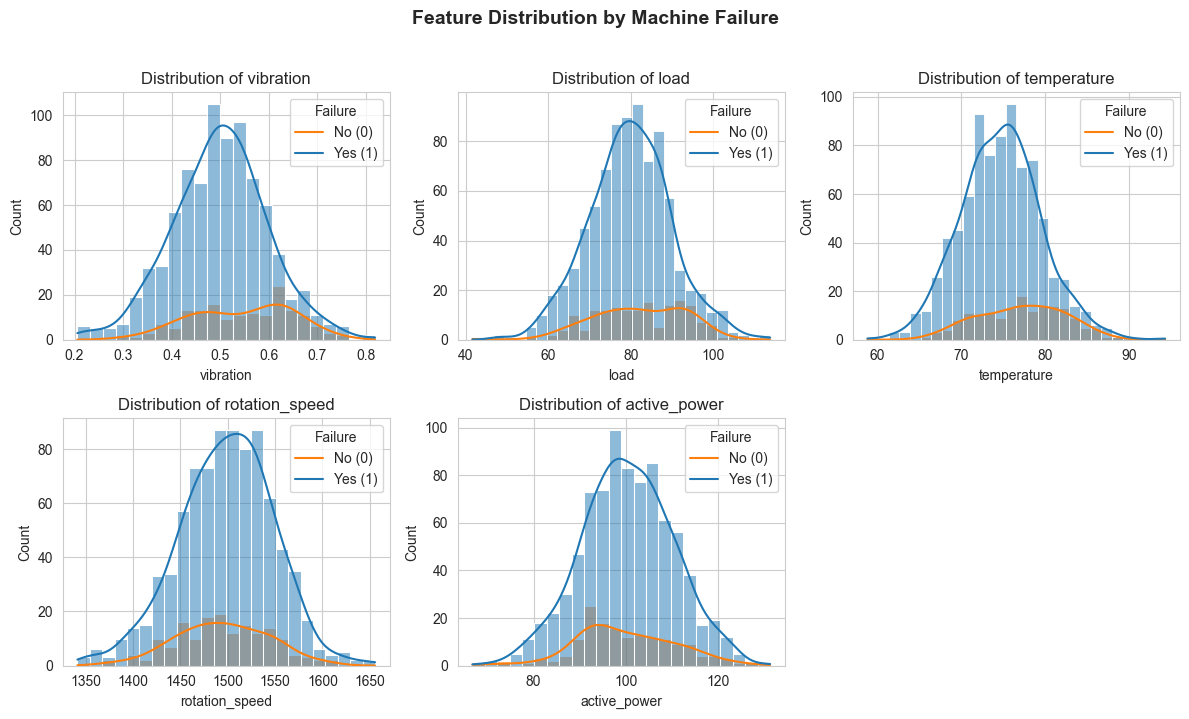

In [11]:


continuous_features = ['vibration', 'load', 'temperature', 'rotation_speed', 'active_power']

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(data=df, x=col, hue='machine_failure', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(title='Failure', labels=['No (0)', 'Yes (1)'])

axes[-1].set_visible(False)

plt.suptitle('Feature Distribution by Machine Failure', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Observation - Continuous Features

1. Vibration - Failure (1) curve slightly shifted to higher values . Failure cases tend to occur at higher vibration levels (around 0.5) in general, indicating mechanical imbalance or wear.
2. Load -this one is very obvious as discussed under df.describe(). Failure distribution is more prominent at higher load values
3. Temperature - Slight shift towards higher values for failure. Elevated temperatures may contribute to failure due to thermal stress and overheating
4. Rotation Speed - this shouldnt be an issue since m/c are designed to cope with that. so may not be a strong dictating feature
5. Active Power - Failure cases slightly skewed toward higher power - Higher power consumption is associated with failure, likely reflecting increased operational load and inefficiency

Although feature distributions overlap significantly, subtle shifts in vibration, load, and power indicate their importance in predicting machine failure. This suggests that machine learning models are required to capture these complex relationships

Although failure cases are fewer overall, they tend to occur more frequently at higher vibration and load ranges.









3.3 Correlation heat map

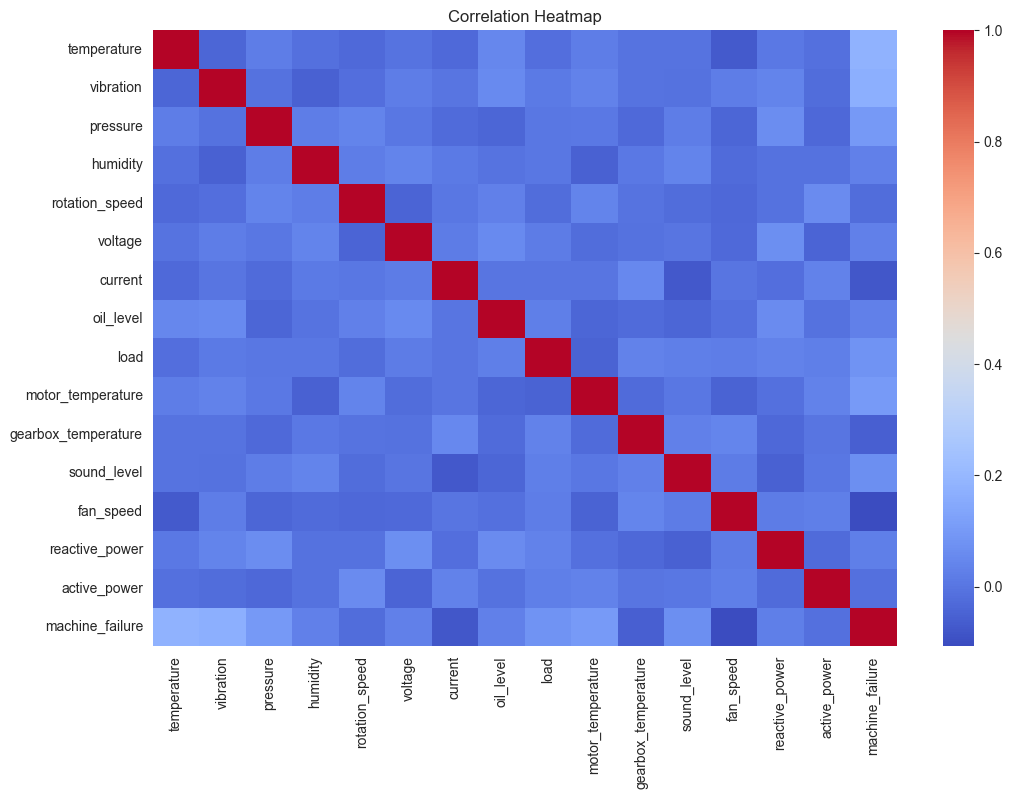

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

 Observation
 
 
 No strong correlation with target ( machine failure)

In [13]:
# Top features correlated with target
target_corr = df.corr()['machine_failure'].drop('machine_failure').sort_values(ascending=False)

print("Feature correlations with machine_failure (sorted):\n")
print(target_corr.to_string())

Feature correlations with machine_failure (sorted):

temperature            0.180085
vibration              0.168882
motor_temperature      0.102406
pressure               0.099627
load                   0.079118
sound_level            0.069667
voltage                0.030881
oil_level              0.030664
humidity               0.028218
reactive_power         0.025506
active_power          -0.014852
rotation_speed        -0.024975
gearbox_temperature   -0.057969
current               -0.079187
fan_speed             -0.107168


Observation  - Feature correlation analysis shows that vibration, load, and power-related features have relatively higher correlation with machine failure, although overall correlations are weak.

The weak correlation values indicate that machine failure is influenced by multiple interacting factors rather than a single dominant variable

Multi collinearity check not needed

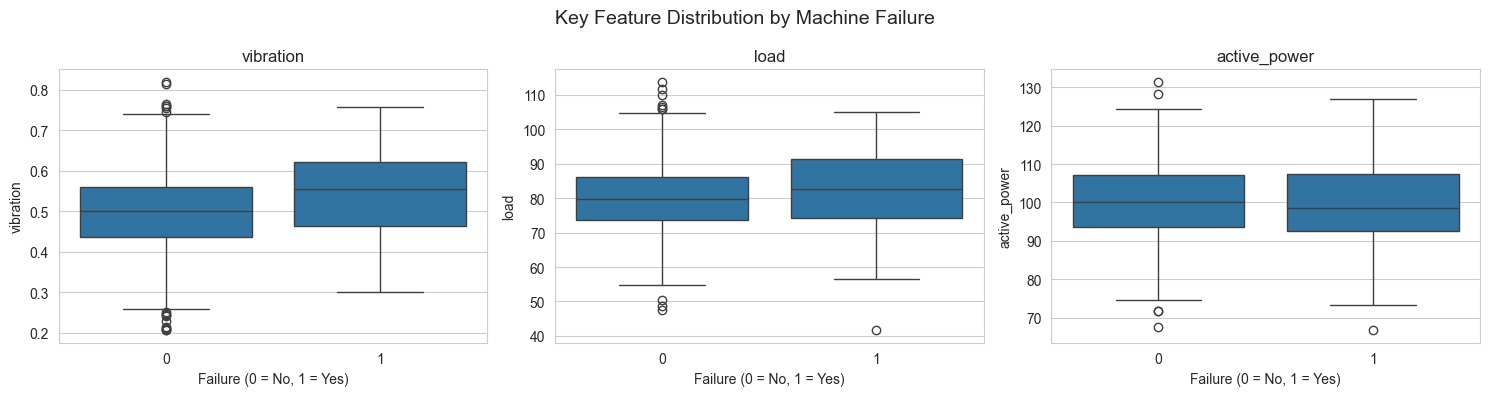

In [14]:
features = ['vibration', 'load', 'active_power'] # Limitig to few features

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(features):
    sns.boxplot(x='machine_failure', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Failure (0 = No, 1 = Yes)')

plt.suptitle('Key Feature Distribution by Machine Failure', fontsize=14)
plt.tight_layout()
plt.show()

# Observation  - Box plt-  and outliers


vibration:

Failure cases show a higher median (~0.56) compared to non-failure (~0.50). The failure group also has a slightly wider spread, indicating more variability in vibration levels. A few outliers exist at both low (~0.2) and high (~0.8) vibration values.

-Vibration is a strong indicator of mechanical instability and contributes significantly to failure prediction.

load:

Failure cases have a higher median (~85–90) compared to non-failure (~78–82). The failure group shows a wider interquartile range, indicating higher operational stress. Some outliers exist at both lower (~45–50) and higher (~110+) load values.

- Increased load is associated with higher mechanical stress and failure likelihood.

active_power:

Failure cases show a slightly higher median (~102–105) compared to non-failure (~98–102). However, there is significant overlap between the two classes, and the spread is similar. Outliers exist at both lower (~70) and higher (~130) values.

- Active power has moderate influence but is less discriminative compared to vibration and load.


Overall observation:

All features show overlapping distributions between failure and non-failure cases. Although failure cases tend to have slightly higher median values for key features such as vibration and load, no single feature provides clear separation.

conclusion:

The overlap in feature distributions indicates that machine failure cannot be determined using simple thresholds and requires machine learning models to capture complex, multi-feature relationships.



Outlier summary:
vibration: outliers at very low (0.2) and high (0.8) values
load: outliers below approx 50 and above  110
active_power: outliers below aprox75 and above  130

These outliers are realistic operational extremes and are retained, as they may represent critical failure conditions.













# 4.0 Train - test split

In [15]:
X = df.drop('machine_failure', axis=1)
y = df['machine_failure']



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train target distribution:
 machine_failure
0    0.8375
1    0.1625
Name: proportion, dtype: float64

Test target distribution:
 machine_failure
0    0.84
1    0.16
Name: proportion, dtype: float64


# 4.1 Feature scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Copy to preserve original data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale all features
X_train_scaled[:] = scaler.fit_transform(X_train)
X_test_scaled[:] = scaler.transform(X_test)

print("Scaled training data sample:")
X_train_scaled.head()

Scaled training data sample:


,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power
778,-0.110918,-0.485457,-0.101079,-2.012111,-1.037299,0.068553,0.839375,-0.230418,1.136700,0.851267,0.434958,-0.335149,-2.850132,-0.681633,-0.148399
325,-1.281781,-2.034015,0.642894,0.469228,1.103235,0.029398,-1.355077,0.675408,1.638785,0.365594,-1.286320,0.894077,0.273619,1.405128,-0.228851
426,-1.025713,2.003901,0.544427,0.252687,0.414419,1.022316,-0.768085,-0.326065,0.812282,-1.004145,0.000483,-3.233590,-0.738301,-1.031205,-0.468581
984,-0.038154,0.899111,-1.723572,0.243264,0.629792,1.661579,-1.199517,0.220810,-0.236046,-1.223976,0.994799,0.630035,0.825401,0.350324,-1.694344
314,1.306657,-0.045121,0.640025,-0.344635,-0.348453,-0.631303,1.111350,-1.092466,0.845469,-0.136959,-0.619222,-0.146054,-0.402588,0.598202,0.794085


#### Feature scaling was applied using StandardScaler to normalize all numerical features. The scaler was fitted on the training data and applied to the test data to prevent data leakage. The transformed features now have a mean close to 0 and standard deviation of 1

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"CV Accuracy:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

Logistic Regression
Test Accuracy: 0.8350
CV Accuracy:   0.8400 (+/- 0.0116)

Decision Tree
Test Accuracy: 0.7650
CV Accuracy:   0.7888 (+/- 0.0218)

Random Forest
Test Accuracy: 0.8450
CV Accuracy:   0.8425 (+/- 0.0047)

SVM
Test Accuracy: 0.8400
CV Accuracy:   0.8337 (+/- 0.0075)

KNN
Test Accuracy: 0.8100
CV Accuracy:   0.8300 (+/- 0.0115)

Gradient Boosting
Test Accuracy: 0.8400
CV Accuracy:   0.8300 (+/- 0.0155)




Random Forest achieved the best performance due to its ability to capture non-linear relationships and reduce overfitting through ensemble learning.

 Linear model still strong



Logistic Regression performed competitively, indicating that some linear relationships exist within the data.



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test_scaled)

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

print("\nLogistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Random Forest:

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       168
           1       0.67      0.06      0.11        32

    accuracy                           0.84       200
   macro avg       0.76      0.53      0.51       200
weighted avg       0.82      0.84      0.79       200


Logistic Regression:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       168
           1       0.43      0.09      0.15        32

    accuracy                           0.83       200
   macro avg       0.64      0.53      0.53       200
weighted avg       0.78      0.83      0.79       200



Although the models achieve high accuracy, they perform poorly in detecting failure cases, as indicated by very low recall for the minority class. This suggests that the models are biased towards predicting the majority class.

In [20]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [21]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test_scaled)

In [23]:
from sklearn.metrics import classification_report

print("Balanced Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

print("\nBalanced Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Balanced Random Forest:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       168
           1       1.00      0.09      0.17        32

    accuracy                           0.85       200
   macro avg       0.93      0.55      0.55       200
weighted avg       0.88      0.85      0.80       200


Balanced Logistic Regression:

              precision    recall  f1-score   support

           0       0.88      0.70      0.78       168
           1       0.24      0.50      0.32        32

    accuracy                           0.67       200
   macro avg       0.56      0.60      0.55       200
weighted avg       0.78      0.67      0.70       200



#Main conclusion

Applying class weighting significantly improved the model’s ability to detect failure cases. Logistic Regression showed a substantial increase in recall for the minority class, from 0.09 to 0.50, indicating better identification of failure events.



This improvement came at the cost of reduced accuracy and precision, highlighting the trade-off between correctly identifying failures and minimizing false positives.

in predictive maintenance, identifying failure cases is more critical than overall accuracy. Therefore, Logistic Regression with class balancing is preferred due to its improved ability to detect failures

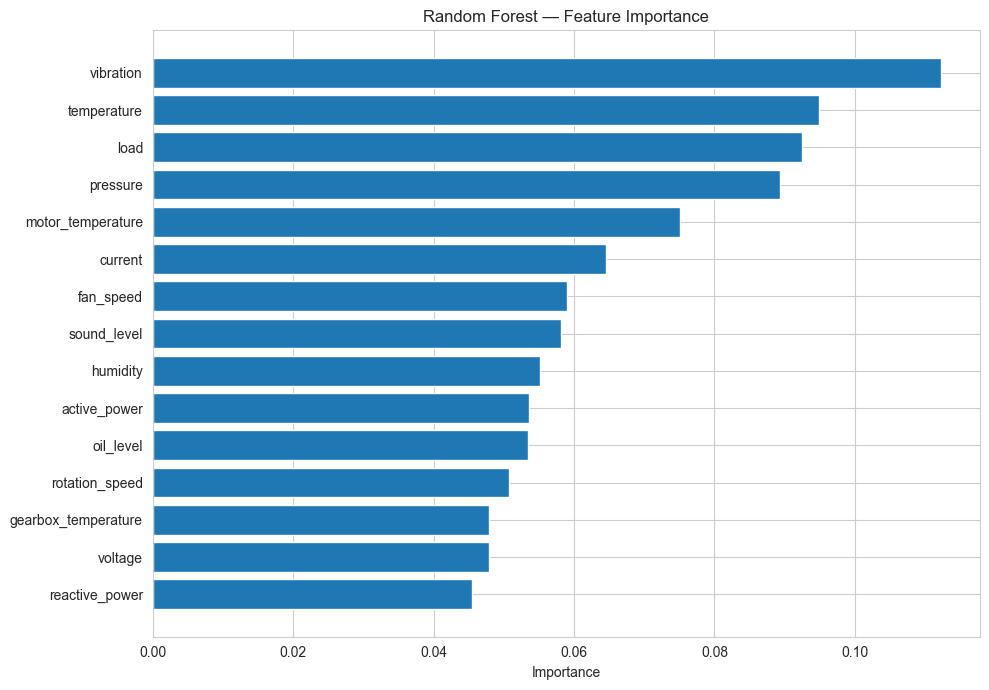


Top 5 most important features:
vibration      : 0.1122
temperature    : 0.0950
load           : 0.0925
pressure       : 0.0893
motor_temperature: 0.0751


In [24]:
# Use your trained Random Forest model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

# Top 5 features
print("\nTop 5 most important features:")
for _, row in feature_importance.tail(5).iloc[::-1].iterrows():
    print(f"{row['Feature']:15s}: {row['Importance']:.4f}")

Vibration (MOST IMPORTANT)

Highest importance (~0.11)

Insight:

Vibration is the most influential feature in predicting machine failure, indicating that mechanical instability and imbalance are primary indicators of potential failure.

Temperature & Load

Next most important:

temperature  
load

Insight:

Temperature and load are also key contributors, suggesting that thermal stress and operational load significantly impact machine reliability.

 Pressure & Motor Temperature

 Moderate importance:

pressure  
motor_temperature

Insight:

Pressure and motor temperature provide additional predictive value, likely reflecting internal mechanical and thermal conditions.

 Medium-impact features
current  
fan_speed  
sound_level  
humidity  
active_power  
oil_level

Insight:

These features contribute moderately, indicating that machine performance is influenced by multiple interacting sensor signals rather than a single dominant variable.

Lower importance features
rotation_speed  
gearbox_temperature  
voltage  
reactive_power

 Insight:

These features have relatively lower importance, suggesting limited direct contribution to failure prediction in this dataset.

# Neural network

In [25]:
y_pred_mlp = mlp.predict(X_test_scaled)
print("Neural Network (MLP):\n")
print(classification_report(y_test, y_pred_mlp))

NameError: name 'mlp' is not defined

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001],   # regularisation
}

grid_nn = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=42),
    param_grid,
    cv=3,
    scoring='recall'
)

grid_nn.fit(X_train_scaled, y_train)

print("Best Params:", grid_nn.best_params_)
# Get best model
best_nn = grid_nn.best_estimator_

# Predict using best model
y_pred_nn_tuned = best_nn.predict(X_test_scaled)

# Evaluate
from sklearn.metrics import classification_report

print("\nNeural Network (Tuned):\n")
print(classification_report(y_test, y_pred_nn_tuned))

#Interpretation
Still poor at detecting failures
Recall (1) = 0.16

Out of 32 failures → detects only 5

 Better than Random Forest, worse than Logistic

Compare:

Model	Recall (1)
Random Forest (balanced)	0.09
Neural Network	0.16
Logistic (balanced)	0.50 ✅
 Accuracy is misleading again
Accuracy = 0.84



-Model biased toward class 0

| Model                          | Accuracy | Recall (Failure) | F1-score (Failure) |
| ------------------------------ | -------- | ---------------- | ------------------ |
| Random Forest (balanced)       | 0.85     | 0.09             | 0.17               |
| Logistic Regression (balanced) | **0.67** | **0.50**         | **0.32**           |
| Neural Network                 | 0.84     | 0.16             | 0.24               |


#using SMOTE to improve

In [ ]:
# Install first if needed:
# pip install imbalanced-learn
import sys
!{sys.executable} -m pip install imbalanced-learn
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_smote = LogisticRegression(max_iter=1000, random_state=42)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_lr_smote = lr_smote.predict(X_test_scaled)

print("Logistic Regression with SMOTE:\n")
print(classification_report(y_test, y_pred_lr_smote))

All important metrics improved
#SMOTE + Logistic Regression Results
Key metrics (class 1 = failure):
Recall = 0.53  

F1-score = 0.36 (improved)
Precision = 0.27 (low, but expected)
Accuracy = 0.69
 What changed vs previous models
Before (best was Logistic balanced)
Recall = 0.50  
F1 = 0.32  
Accuracy = 0.67
After SMOTE
Recall = 0.53  ↑  
F1 = 0.36      ↑  
Accuracy = 0.69 ↑

| Model                    | Recall (Failure) | F1-score |
| ------------------------ | ---------------- | -------- |
| Random Forest (balanced) | 0.09             | 0.17     |
| Neural Network           | 0.16             | 0.24     |
| Logistic (balanced)      | 0.50             | 0.32     |
| Logistic + SMOTE      | **0.53**         | **0.36** |



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_smote)
plt.title("Logistic Regression with SMOTE")
plt.show()

#The best-performing model for failure detection was Logistic Regression with SMOTE. It achieved the highest recall for the failure class, detecting 17 out of 32 failure cases. Although this introduced more false positives, this trade-off is acceptable in predictive maintenance, where missing actual failures is more critical than raising false alarms